# Notebook 1: Synthetic Dataset Exploration

**Goal:** Load the synthetic dataset, understand its structure, and validate that the designed signals are present.

**Dataset:** Synthetically generated — 4939 dishes (LLM-generated) × 1100 users × ~195K interactions.

Why synthetic? Food.com lacks user profiles, orders, and nutritional context — signals that are critical for a production food recommender. See [the case study README](../README.md) for the full motivation.

After this notebook you will understand:
- Dish distribution across 8 cuisine clusters
- User type breakdown (archetype / hybrid / contradictory / drifting)
- Interaction patterns (views, orders, ratings, favorites)
- Signal validation: cuisine coherence, calorie goals, allergen safety

In [1]:
# ============================================================
# SETUP: clone repo, install deps, add src to path
# ============================================================
import os, sys

REPO = "Embedding-Based-Recommender"
GITHUB_USER = "IldarRakiev"

ENV = 'kaggle' if os.path.exists('/kaggle/working') else 'colab' if os.path.exists('/content') else 'local'
BASE = '/kaggle/working' if ENV == 'kaggle' else '/content' if ENV == 'colab' else os.path.abspath('..')
REPO_DIR = f'{BASE}/{REPO}' if ENV != 'local' else os.path.abspath('..')

if ENV != 'local':
    if not os.path.exists(REPO_DIR):
        os.system(f'git clone https://github.com/{GITHUB_USER}/{REPO}.git {REPO_DIR}')
    else:
        os.system(f'cd {REPO_DIR} && git pull -q')
    os.system('pip install -q sentence-transformers faiss-cpu pandas pyarrow matplotlib seaborn umap-learn plotly scikit-learn tqdm')

sys.path.insert(0, f'{REPO_DIR}/food-recsys-embeddings/src')
print(f"Environment: {ENV} | Repo: {REPO_DIR}")
print("Setup complete")

Cloning into '/kaggle/working/Embedding-Based-Recommender'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 61.4 MB/s eta 0:00:00
Environment: kaggle | Repo: /kaggle/working/Embedding-Based-Recommender
Setup complete


In [3]:
# ============================================================
# DATA PATHS
# ============================================================
import os

SYNTHETIC_DIR = os.path.join(REPO_DIR, 'data', 'synthetic')
assert os.path.exists(SYNTHETIC_DIR), f"Synthetic data not found at {SYNTHETIC_DIR}. Run data/generate_synthetic.py first."
print(f"Synthetic data: {SYNTHETIC_DIR}")
print("Files:", os.listdir(SYNTHETIC_DIR))

Synthetic data: /kaggle/working/Embedding-Based-Recommender/data/synthetic
Files: ['interactions.parquet', 'interactions_test.parquet', 'allergens.parquet', 'interactions_train.parquet', 'dishes.parquet', 'interactions_val.parquet', 'users.parquet']


## 1. Load Data

In [4]:
import pandas as pd
import numpy as np

dishes = pd.read_parquet(f'{SYNTHETIC_DIR}/dishes.parquet')
users = pd.read_parquet(f'{SYNTHETIC_DIR}/users.parquet')
interactions = pd.read_parquet(f'{SYNTHETIC_DIR}/interactions.parquet')
train = pd.read_parquet(f'{SYNTHETIC_DIR}/interactions_train.parquet')
val = pd.read_parquet(f'{SYNTHETIC_DIR}/interactions_val.parquet')
test = pd.read_parquet(f'{SYNTHETIC_DIR}/interactions_test.parquet')

print(f"Dishes:       {len(dishes):,} rows, {dishes.columns.tolist()}")
print(f"Users:        {len(users):,} rows, {users.columns.tolist()}")
print(f"Interactions: {len(interactions):,} rows")
print(f"Split:        train={len(train):,} | val={len(val):,} | test={len(test):,}")
dishes.head(2)

Dishes:       4,939 rows, ['name', 'description', 'recipe_text', 'ingredients', 'calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'allergen_tags', 'meal_time', 'price_tier', 'tag_list', 'cuisine_cluster', 'id', 'alergen_tags']
Users:        1,100 rows, ['user_id', 'user_type', 'archetype_name', 'goal_type', 'activity_level', 'gender', 'age', 'height_cm', 'weight_kg', 'has_diabetes', 'price_level', 'allergens', 'kcal_target', 'protein_target_g', 'fat_target_g', 'carbs_target_g']
Interactions: 195,749 rows
Split:        train=117,449 | val=39,150 | test=39,150


,name,description,recipe_text,ingredients,calories,protein_g,fat_g,carbs_g,fiber_g,allergen_tags,meal_time,price_tier,tag_list,cuisine_cluster,id,alergen_tags
0,Kholodets,Kholodets is a traditional chilled meat jelly ...,"1. In a large pot, combine 1 kg of pork shank,...","[pork shank, beef, water, salt, onion, carrots...",150,20.0,7.0,1.0,0.0,[],lunch,medium,"[savory, traditional, gelatinous]",0,1,None
1,Kasha Varnishkes,Kasha Varnishkes is a hearty dish of buckwheat...,"1. In a skillet, heat 2 tablespoons of vegetab...","[buckwheat, bowtie pasta, onion, mushrooms, ve...",210,6.0,5.0,38.0,3.0,[gluten],lunch,low,"[hearty, comfort, nutty]",0,2,None


## 2. Dish Distribution

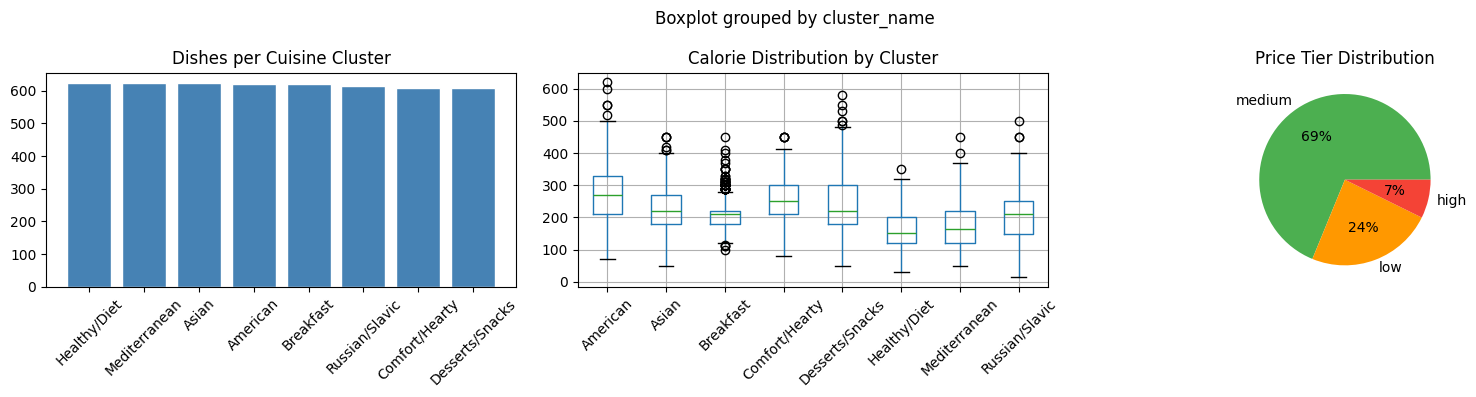


Calorie stats: min=15, max=620, mean=216
Meal times: {'dinner': 1819, 'lunch': 1079, 'snack': 1011, 'breakfast': 977, 'dessert': 31, 'side': 18, 'appetizer': 4}


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

CLUSTER_NAMES = {
    0: 'Russian/Slavic', 1: 'Mediterranean', 2: 'Asian',
    3: 'American', 4: 'Healthy/Diet', 5: 'Comfort/Hearty',
    6: 'Breakfast', 7: 'Desserts/Snacks'
}
dishes['cluster_name'] = dishes['cuisine_cluster'].map(CLUSTER_NAMES)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Cuisine clusters
cluster_counts = dishes['cluster_name'].value_counts()
axes[0].bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Dishes per Cuisine Cluster')
axes[0].tick_params(axis='x', rotation=45)

# Calorie distribution by cluster
dishes.boxplot(column='calories', by='cluster_name', ax=axes[1], rot=45)
axes[1].set_title('Calorie Distribution by Cluster')
axes[1].set_xlabel('')
plt.sca(axes[1]); plt.title('Calorie Distribution by Cluster')

# Price tier
price_counts = dishes['price_tier'].value_counts()
axes[2].pie(price_counts.values, labels=price_counts.index, autopct='%1.0f%%', colors=['#4CAF50','#FF9800','#F44336'])
axes[2].set_title('Price Tier Distribution')

plt.tight_layout()
plt.show()

print(f"\nCalorie stats: min={dishes['calories'].min()}, max={dishes['calories'].max()}, mean={dishes['calories'].mean():.0f}")
print(f"Meal times: {dishes['meal_time'].value_counts().to_dict()}")

## 3. User Distribution

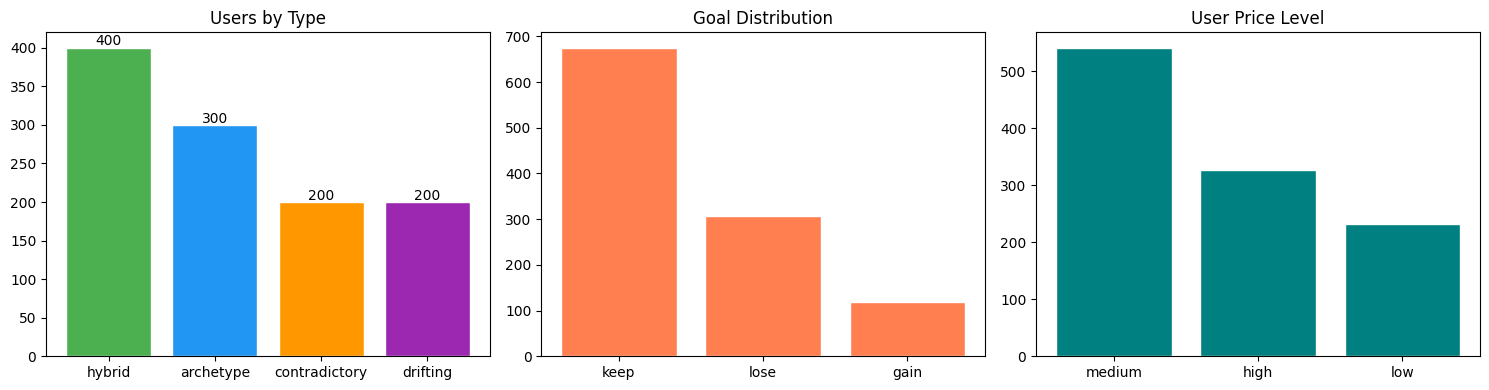


Archetype breakdown: {'fitness': 30, 'student': 30, 'health_mom': 30, 'muscle_builder': 30, 'vegetarian': 30, 'gluten_free': 30, 'traditional': 30, 'allergy_prone': 30, 'strict_dieter': 30, 'foodie_explorer': 30}
Allergen prevalence: 341 users (31%) have allergens


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# User types
type_counts = users['user_type'].value_counts()
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
axes[0].bar(type_counts.index, type_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Users by Type')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=10)

# Goal distribution
goal_counts = users['goal_type'].value_counts()
axes[1].bar(goal_counts.index, goal_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Goal Distribution')

# Price level
price_counts = users['price_level'].value_counts()
axes[2].bar(price_counts.index, price_counts.values, color='teal', edgecolor='white')
axes[2].set_title('User Price Level')

plt.tight_layout()
plt.show()

print(f"\nArchetype breakdown: {users[users['user_type']=='archetype']['archetype_name'].value_counts().to_dict()}")
print(f"Allergen prevalence: {(users['allergens'].apply(len) > 0).sum()} users ({(users['allergens'].apply(len) > 0).mean():.0%}) have allergens")

## 4. Interaction Patterns

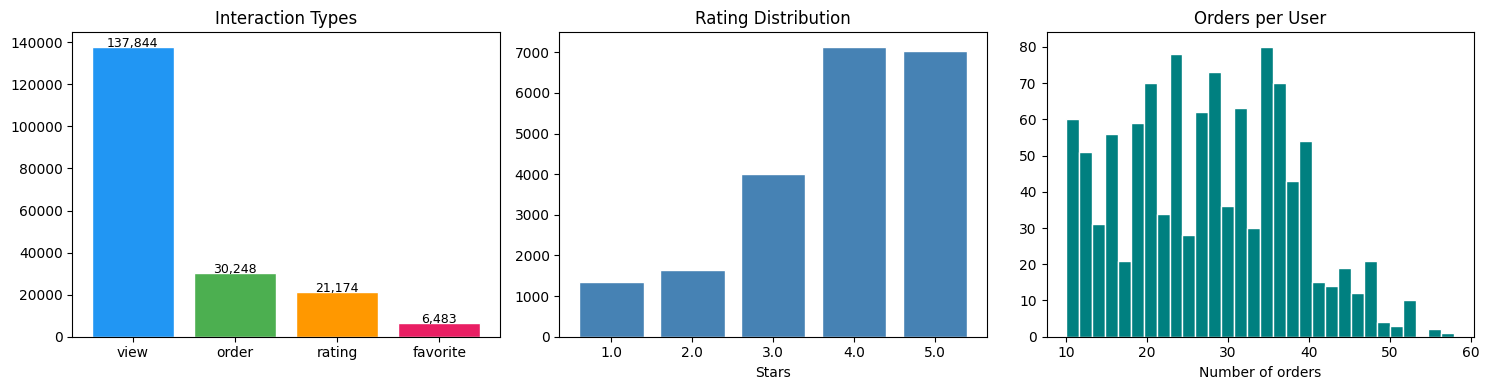


Avg orders per user: 27.5
Avg views per user: 125.3
Users with >=5 orders in test: 799


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Interaction types
type_counts = interactions['interaction_type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color=['#2196F3','#4CAF50','#FF9800','#E91E63'], edgecolor='white')
axes[0].set_title('Interaction Types')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Rating distribution (orders that were rated)
ratings = interactions[interactions['interaction_type'] == 'rating']['rating'].dropna()
rating_counts = ratings.value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(str), rating_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Rating Distribution')
axes[1].set_xlabel('Stars')

# Orders per user
orders_per_user = interactions[interactions['interaction_type'] == 'order'].groupby('user_id').size()
axes[2].hist(orders_per_user, bins=30, color='teal', edgecolor='white')
axes[2].set_title('Orders per User')
axes[2].set_xlabel('Number of orders')

plt.tight_layout()
plt.show()

print(f"\nAvg orders per user: {orders_per_user.mean():.1f}")
print(f"Avg views per user: {interactions[interactions['interaction_type']=='view'].groupby('user_id').size().mean():.1f}")
print(f"Users with >=5 orders in test: {(test[test['interaction_type'].isin(['order','favorite'])].groupby('user_id').size() >= 5).sum()}")

## 5. Signal Validation

In [10]:
# Signal 1: Cuisine coherence — do orders match user's preferred cuisines?
from ast import literal_eval

dish_cluster = dict(zip(dishes['id'], dishes['cuisine_cluster']))

orders = interactions[interactions['interaction_type'] == 'order'].copy()
orders['cuisine_cluster'] = orders['dish_id'].map(dish_cluster)

# For archetype users, check if ordered cluster matches preferred cuisines
archetype_users_full = pd.read_parquet(f'{SYNTHETIC_DIR}/users.parquet')

# Signal 2: Calorie coherence — lose vs gain users
users_df = pd.read_parquet(f'{SYNTHETIC_DIR}/users.parquet')
dish_calories = dict(zip(dishes['id'], dishes['calories']))
orders['calories'] = orders['dish_id'].map(dish_calories)
orders_with_goal = orders.merge(users_df[['user_id', 'goal_type']], on='user_id')

lose_cal = orders_with_goal[orders_with_goal['goal_type'] == 'lose']['calories'].mean()
gain_cal = orders_with_goal[orders_with_goal['goal_type'] == 'gain']['calories'].mean()
keep_cal = orders_with_goal[orders_with_goal['goal_type'] == 'keep']['calories'].mean()

print("=== Signal Validation ===")
print(f"\nCalorie coherence (lower = better for 'lose' goal):")
print(f"  lose users avg calories: {lose_cal:.0f}")
print(f"  keep users avg calories: {keep_cal:.0f}")
print(f"  gain users avg calories: {gain_cal:.0f}")
print(f"  → lose < gain: {'✓ PASS' if lose_cal < gain_cal else '✗ FAIL'}")

# Signal 3: Allergen safety
allergen_df = pd.read_parquet(f'{SYNTHETIC_DIR}/allergens.parquet')
dish_allergens = {row['id']: set(row['allergen_tags']) if isinstance(row['allergen_tags'], list) else set()
                  for _, row in dishes.iterrows()}
user_allergens = allergen_df.groupby('user_id')['allergen'].apply(set).to_dict()

order_fav = interactions[interactions['interaction_type'].isin(['order', 'favorite'])]
violations = 0
for _, row in order_fav.iterrows():
    u_all = user_allergens.get(row['user_id'], set())
    d_all = dish_allergens.get(row['dish_id'], set())
    if u_all & d_all:
        violations += 1
print(f"\nAllergen violations in orders/favorites: {violations} → {'✓ PASS' if violations == 0 else '✗ FAIL'}")

=== Signal Validation ===

Calorie coherence (lower = better for 'lose' goal):
  lose users avg calories: 188
  keep users avg calories: 201
  gain users avg calories: 220
  → lose < gain: ✓ PASS

Allergen violations in orders/favorites: 0 → ✓ PASS


## 6. Sample Dish

In [11]:
sample = dishes[dishes['cuisine_cluster'] == 0].iloc[0]
print(f"Name: {sample['name']}")
print(f"Cluster: {CLUSTER_NAMES[sample['cuisine_cluster']]}")
print(f"Description: {sample['description']}")
print(f"Ingredients: {sample['ingredients']}")
print(f"Nutrition: {sample['calories']} kcal | {sample['protein_g']}g protein | {sample['fat_g']}g fat | {sample['carbs_g']}g carbs")
print(f"Allergens: {sample['allergen_tags']}")
print(f"Meal time: {sample['meal_time']} | Price: {sample['price_tier']}")
print(f"\nRecipe preview:\n{sample['recipe_text'][:400]}")

Name: Kholodets
Cluster: Russian/Slavic
Description: Kholodets is a traditional chilled meat jelly that is rich and savory, typically served as an appetizer. Its unique texture and gelatinous consistency are balanced by the flavors of seasoned meat and aromatic spices.
Ingredients: ['pork shank' 'beef' 'water' 'salt' 'onion' 'carrots' 'gelatin']
Nutrition: 150 kcal | 20.0g protein | 7.0g fat | 1.0g carbs
Allergens: []
Meal time: lunch | Price: medium

Recipe preview:
1. In a large pot, combine 1 kg of pork shank, 500 g of beef, 3 liters of water, and 1 teaspoon of salt. Bring to a boil over medium-high heat, skimming off any foam. 2. Reduce the heat, add 1 onion and 2 carrots (whole), and simmer for 4 hours. 3. Remove the meat, strain the broth, and cool. Once cooled, chop the meat into small pieces. 4. In a deep dish, layer the meat and pour enough broth to c


In [21]:
# ml/ml/text_builders.py
"""
Модуль для построения текстовых представлений блюд и пользователей
для последующего преобразования в эмбеддинги.
"""
from __future__ import annotations

import math
import re
from typing import Any
from datetime import date


# ============================================
# MACRO TOKENS - категоризация нутриентов
# ============================================

def macro_tokens(kcal: float, p: float, f: float, c: float) -> list[str]:
    """Generate discrete macro-nutrient category tokens.

    .. deprecated::
        No longer used in ``dish_to_rich_text()`` because discrete
        thresholds create artificial cluster boundaries in embedding space.
        Kept for backward compatibility. Prefer continuous ratios in the
        NUTRITION line instead.

    Args:
        kcal: Calories per 100 g.
        p: Protein grams per 100 g.
        f: Fat grams per 100 g.
        c: Carbs grams per 100 g.

    Returns:
        List of category tokens such as ``["HIGH_PROTEIN", "LOW_FAT", ...]``.
    """
    tokens = []

    # protein
    if p >= 40:
        tokens.append("VERY_HIGH_PROTEIN")
    elif p >= 25:
        tokens.append("HIGH_PROTEIN")
    elif p >= 15:
        tokens.append("MEDIUM_PROTEIN")
    else:
        tokens.append("LOW_PROTEIN")

    # fat
    if f >= 30:
        tokens.append("HIGH_FAT")
    elif f >= 15:
        tokens.append("MEDIUM_FAT")
    else:
        tokens.append("LOW_FAT")

    # carbs
    if c >= 50:
        tokens.append("HIGH_CARB")
    elif c >= 25:
        tokens.append("MEDIUM_CARB")
    else:
        tokens.append("LOW_CARB")

    # Dominant macro
    total = max(p + f + c, 1e-6)
    pr = p / total
    cr = c / total
    fr = f / total

    if pr >= cr and pr >= fr:
        tokens.append("PROTEIN_DOMINANT")
    elif cr >= pr and cr >= fr:
        tokens.append("CARB_DOMINANT")
    else:
        tokens.append("FAT_DOMINANT")

    # Calorie category
    if kcal < 300:
        tokens.append("LOW_CALORIE")
    elif kcal < 600:
        tokens.append("MEDIUM_CALORIE")
    else:
        tokens.append("HIGH_CALORIE")

    return tokens


# ============================================
# INGREDIENT EXTRACTION
# ============================================

_COOKING_VERBS_RE = re.compile(
    r"\b(?:"
    r"add|mix|combine|cook|bake|fry|boil|stir|whisk|chop|slice|dice|season|marinate|simmer"
    r"|roast|grill|blend|mince|peel|cut|fold|bring|reduce|remove|strain|cool|chill|serve|skim"
    r"|layer|pour|cover|garnish|heat|drain"
    r"|нарезать|нарежьте|добавить|добавьте|смешать|смешайте|обжарить|обжарьте"
    r"|варить|варите|тушить|тушите|запечь|запекать|залить|залейте|посолить"
    r"|поперчить|перемешать|перемешайте|взбить|взбейте|положить|положите"
    r"|натереть|натрите|очистить|очистите|порезать|порежьте"
    r")\b",
    re.IGNORECASE,
)


def _scalar_float(val: Any, default: float = 0.0) -> float:
    """Coerce pandas/numpy scalars; map NaN/inf to default."""
    if val is None:
        return default
    try:
        x = float(val)
    except (TypeError, ValueError):
        return default
    if math.isnan(x) or math.isinf(x):
        return default
    return x


def _pick_kcal(dish: dict) -> float:
    """Prefer explicit calories; avoid ``or`` chains so 0 does not hide other keys."""
    for key in ("calories", "kcal_per_100g", "kcal_per_portion"):
        if key not in dish:
            continue
        v = _scalar_float(dish.get(key))
        if v > 0:
            return v
    if "calories" in dish:
        return _scalar_float(dish.get("calories"))
    if "kcal_per_100g" in dish:
        return _scalar_float(dish.get("kcal_per_100g"))
    if "kcal_per_portion" in dish:
        return _scalar_float(dish.get("kcal_per_portion"))
    return 0.0


def _pick_macro_g(dish: dict, *keys: str) -> float:
    for key in keys:
        if key in dish and dish[key] is not None:
            return _scalar_float(dish[key])
    for key in keys:
        v = dish.get(key)
        if v is not None:
            return _scalar_float(v)
    return 0.0


def _as_clean_str(val: Any) -> str:
    if val is None:
        return ""
    s = str(val).strip()
    if not s or s.lower() in ("nan", "none", "<na>"):
        return ""
    return s


def _ingredients_list(dish: dict) -> list[str]:
    """Normalize ingredients from list / tuple / ndarray (parquet / ``to_dict()``)."""
    raw = dish.get("ingredients")
    if raw is None:
        return []
    if hasattr(raw, "tolist"):
        try:
            raw = raw.tolist()
        except Exception:
            return []
    if isinstance(raw, (list, tuple)):
        out: list[str] = []
        for x in raw:
            if x is None:
                continue
            s = str(x).strip()
            if s and s.lower() not in ("nan", "none"):
                out.append(s)
        return out
    return []


def extract_ingredients(recipe_text: str) -> list[str]:
    """Extract ingredient names from a recipe text using heuristic parsing.

    Supported formats:
    - Bullet lists (lines starting with ``-``, ``*``, or ``•``)
    - Numbered lists (``1. ..``, ``1) ..``)
    - Comma-separated items preceding a cooking verb

    Args:
        recipe_text: Raw recipe text (may be empty).

    Returns:
        Deduplicated list of ingredient strings. Empty if extraction fails.

    Example:
        >>> extract_ingredients("- 200г куриной грудки\\n- 100г риса\\nНарезать кубиками.")
        ['200г куриной грудки', '100г риса']
    """
    if not recipe_text or not recipe_text.strip():
        return []

    ingredients: list[str] = []
    seen: set[str] = set()

    for line in recipe_text.splitlines():
        stripped = line.strip()
        # Bullet / numbered list items
        match = re.match(r"^(?:[-*•]|\d+[.)]\s*)\s*(.+)", stripped)
        if match:
            item = match.group(1).strip().rstrip(".,;")
            if item and not _COOKING_VERBS_RE.search(item):
                key = item.lower()
                if key not in seen:
                    seen.add(key)
                    ingredients.append(item)

    if ingredients:
        return ingredients

    # Fallback: comma-separated tokens before a cooking verb
    for line in recipe_text.splitlines():
        verb_match = _COOKING_VERBS_RE.search(line)
        if verb_match:
            before = line[: verb_match.start()]
            parts = [p.strip().rstrip(".,;") for p in before.split(",")]
            for p in parts:
                if p and len(p) > 1:
                    key = p.lower()
                    if key not in seen:
                        seen.add(key)
                        ingredients.append(p)

    return ingredients


# ============================================
# DISH TEXT BUILDER
# ============================================

def dish_to_rich_text(
    dish: dict,
    tags: list[str] | None = None,
    include_recipe: bool = False,
    include_macro_tokens: bool = False,
    include_ratios: bool = True,
    include_ingredients: bool = True,
    context: str | None = None,
) -> str:
    """
    Преобразует блюдо в rich text для эмбеддинга.

    Args:
        dish: словарь с полями id, name, short_description, recipe_text,
              kcal_per_100g, protein_g_per_100g, fat_g_per_100g, carbs_g_per_100g, fiber_g_per_100g
        tags: список строковых тегов (если есть dish_tags)
        include_recipe: включить текст рецепта (по умолчанию False — убираем как шум)
        include_macro_tokens: включить дискретные MACRO_TAGS токены (по умолчанию False — deprecated)
        include_ratios: включить непрерывные protein_ratio/fat_ratio/carb_ratio (по умолчанию True)
        include_ingredients: извлечь и включить список ингредиентов (по умолчанию True)
        context: контекст приёма пищи ('breakfast', 'lunch', 'dinner', 'snack')

    Returns:
        Строка с текстовым описанием блюда

    Пример вывода:
        DISH_NAME: Куриная грудка с овощами
        DESCRIPTION: Легкое диетическое блюдо
        NUTRITION: 350 kcal, 45g protein, 8g fat, 15g carbs, 5g fiber | protein_ratio: 0.51, fat_ratio: 0.21, carb_ratio: 0.17
        TAGS: диетическое птица
        INGREDIENTS: куриная грудка, помидоры, базилик
    """
    name = _as_clean_str(dish.get("name")) or _as_clean_str(dish.get("title"))
    desc = _as_clean_str(dish.get("description")) or _as_clean_str(dish.get("short_description"))
    recipe = _as_clean_str(dish.get("recipe_text")) or _as_clean_str(dish.get("instructions"))

    kcal = _pick_kcal(dish)
    p = _pick_macro_g(dish, "protein_g", "protein_g_per_100g")
    fat = _pick_macro_g(dish, "fat_g", "fat_g_per_100g")
    c = _pick_macro_g(dish, "carbs_g", "carbs_g_per_100g")
    fiber = _pick_macro_g(dish, "fiber_g", "fiber_g_per_100g")
    if kcal <= 0 and (p + fat + c) > 0:
        kcal = 4 * p + 9 * fat + 4 * c

    # Context line goes first — sentence-transformers weight early tokens more
    parts = []
    if context:
        _CONTEXT_DESCRIPTIONS = {
            "breakfast": "CONTEXT: breakfast meal, energizing morning food",
            "lunch": "CONTEXT: lunch, main meal of the day, substantial",
            "dinner": "CONTEXT: dinner, evening meal, lighter option",
            "snack": "CONTEXT: snack, quick light bite between meals",
        }
        parts.append(_CONTEXT_DESCRIPTIONS.get(context, f"CONTEXT: {context}"))

    nutrition = (
        f"NUTRITION: {kcal:.0f} kcal, {p:.0f}g protein, "
        f"{fat:.0f}g fat, {c:.0f}g carbs, {fiber:.0f}g fiber"
    )
    if include_ratios and kcal > 0:
        pr = (p * 4) / kcal
        fr = (fat * 9) / kcal
        cr = (c * 4) / kcal
        nutrition += (
            f" | protein_ratio: {pr:.2f}, fat_ratio: {fr:.2f}, carb_ratio: {cr:.2f}"
        )

    parts += [f"DISH_NAME: {name}"]
    if desc:
        parts.append(f"DESCRIPTION: {desc}")
    parts.append(nutrition)

    if include_macro_tokens:
        tokens = macro_tokens(kcal, p, fat, c)
        parts.append("MACRO_TAGS: " + " ".join(tokens))

    # Normalize tags: parquet / pandas may pass numpy.ndarray; bool(ndarray) raises
    tag_list: list[str] = []
    if tags is not None:
        seq = tags.tolist() if hasattr(tags, "tolist") else list(tags)
        tag_list = [str(t) for t in seq]
    if tag_list:
        parts.append("TAGS: " + " ".join(tag_list))

    if include_ingredients:
        structured = _ingredients_list(dish)
        if structured:
            parts.append("INGREDIENTS: " + ", ".join(structured))
        elif recipe:
            ingredients = extract_ingredients(recipe)
            if ingredients:
                parts.append("INGREDIENTS: " + ", ".join(ingredients))

    if include_recipe and recipe:
        parts.append("RECIPE_BRIEF: " + recipe[:400])

    return "\n".join(parts)


# ============================================
# USER STATIC TEXT BUILDER
# ============================================

def user_static_to_text(
    profile: dict | None,
    allergens: list[dict] | None,
    habits: dict | None,
) -> str:
    """
    Статический профиль пользователя (меняется редко).
    
    Args:
        profile: UserProfile данные (goal_type, activity_level, has_diabetes, etc.)
        allergens: список UserAllergen записей
        habits: UserHabits данные
    
    Returns:
        Текстовое представление статического профиля
    """
    parts = ["USER STATIC PROFILE:"]
    
    if profile:
        # Goal
        goal = profile.get("goal_type")
        if goal:
            goal_text = {
                "lose": "GOAL: WEIGHT LOSS",
                "keep": "GOAL: MAINTAIN WEIGHT",
                "gain": "GOAL: WEIGHT GAIN",
            }.get(goal, f"GOAL: {goal.upper()}")
            parts.append(goal_text)
        
        # Activity
        activity = profile.get("activity_level")
        if activity:
            parts.append(f"ACTIVITY: {activity.upper()}")
        
        # Medical conditions
        conditions = []
        if profile.get("has_diabetes"):
            conditions.append("DIABETES")
        if profile.get("other_conditions"):
            conditions.append(profile["other_conditions"].upper())
        if conditions:
            parts.append("MEDICAL: " + ", ".join(conditions))
        
        # Budget
        price_level = profile.get("price_level")
        if price_level:
            parts.append(f"BUDGET: {price_level.upper()}")
    
    # Allergens
    if allergens:
        allergen_names = [a.get("allergen_name", "").upper() for a in allergens if a.get("allergen_name")]
        if allergen_names:
            parts.append("ALLERGIES: " + ", ".join(f"NO {a}" for a in allergen_names))
    
    return "\n".join(parts)


# ============================================
# USER DYNAMIC TEXT BUILDER
# ============================================

def user_dynamic_to_text(
    daily_targets: dict | None,
    day_stats: dict | None,
    meal_time: str | None = None,
) -> str:
    """
    Динамический профиль пользователя (меняется в течение дня).
    
    Args:
        daily_targets: UserDailyTargets данные (kcal_target, protein_target_g, etc.)
        day_stats: UserDayStats данные (kcal_consumed, protein_g consumed today, etc.)
        meal_time: тип приёма пищи ('breakfast', 'lunch', 'dinner', 'snack')
    
    Returns:
        Текстовое представление динамического состояния
    """
    parts = ["TODAY STATUS:"]
    
    # Потреблено сегодня
    if day_stats:
        consumed_kcal = int(day_stats.get("kcal_consumed") or 0)
        consumed_p = float(day_stats.get("protein_g") or 0)
        consumed_f = float(day_stats.get("fat_g") or 0)
        consumed_c = float(day_stats.get("carbs_g") or 0)
        parts.append(
            f"CONSUMED TODAY: {consumed_kcal} kcal, {consumed_p:.0f}g protein, "
            f"{consumed_f:.0f}g fat, {consumed_c:.0f}g carbs"
        )
    
    # Остаток от целей (cold start: при отсутствии day_stats считаем consumed=0)
    if daily_targets:
        target_kcal = int(daily_targets.get("kcal_target") or 2000)
        target_p = float(daily_targets.get("protein_target_g") or 100)
        target_f = float(daily_targets.get("fat_target_g") or 65)
        target_c = float(daily_targets.get("carbs_target_g") or 250)
        
        consumed_kcal = int(day_stats.get("kcal_consumed") or 0) if day_stats else 0
        consumed_p = float(day_stats.get("protein_g") or 0) if day_stats else 0
        consumed_f = float(day_stats.get("fat_g") or 0) if day_stats else 0
        consumed_c = float(day_stats.get("carbs_g") or 0) if day_stats else 0
        
        remaining_kcal = max(0, target_kcal - consumed_kcal)
        remaining_p = max(0, target_p - consumed_p)
        remaining_f = max(0, target_f - consumed_f)
        remaining_c = max(0, target_c - consumed_c)
        
        parts.append(
            f"REMAINING: {remaining_kcal} kcal, {remaining_p:.0f}g protein, "
            f"{remaining_f:.0f}g fat, {remaining_c:.0f}g carbs"
        )
        
        # Что нужно больше всего
        needs = []
        p_ratio = remaining_p / max(target_p, 1)
        f_ratio = remaining_f / max(target_f, 1)
        c_ratio = remaining_c / max(target_c, 1)
        
        if p_ratio > 0.5:
            needs.append("NEEDS_PROTEIN")
        if c_ratio > 0.5:
            needs.append("NEEDS_CARBS")
        if f_ratio > 0.5:
            needs.append("NEEDS_FAT")
        if remaining_kcal < 300:
            needs.append("LOW_CALORIES_LEFT")
        
        if needs:
            parts.append("NEEDS: " + " ".join(needs))
    
    # Время приёма пищи
    if meal_time:
        meal_text = {
            "breakfast": "MEAL_TIME: BREAKFAST - looking for energizing start",
            "lunch": "MEAL_TIME: LUNCH - main meal of the day",
            "dinner": "MEAL_TIME: DINNER - lighter evening meal",
            "snack": "MEAL_TIME: SNACK - quick light bite",
        }.get(meal_time.lower(), f"MEAL_TIME: {meal_time.upper()}")
        parts.append(meal_text)
    
    return "\n".join(parts)


# ============================================
# USER BEHAVIORAL TEXT BUILDER
# ============================================

def user_behavior_to_text(
    recent_views: list[dict] | None = None,
    recent_orders: list[dict] | None = None,
    favorites: list[dict] | None = None,
    top_tags: list[str] | None = None,
) -> str:
    """
    Поведенческий профиль пользователя (история взаимодействий).
    
    Args:
        recent_views: список недавно просмотренных блюд [{"name": "...", "dish_id": ...}, ...]
        recent_orders: список недавно заказанных блюд
        favorites: список избранных блюд
        top_tags: наиболее частые теги в истории
    
    Returns:
        Текстовое представление поведенческого профиля
    """
    parts = ["USER BEHAVIOR:"]
    
    # Недавние просмотры
    if recent_views:
        names = [v.get("name", "") for v in recent_views[:10] if v.get("name")]
        if names:
            parts.append("RECENTLY VIEWED: " + ", ".join(names))
    
    # Недавние заказы
    if recent_orders:
        names = [o.get("name", "") for o in recent_orders[:10] if o.get("name")]
        if names:
            parts.append("RECENTLY ORDERED: " + ", ".join(names))
    
    # Избранное
    if favorites:
        names = [f.get("name", "") for f in favorites[:10] if f.get("name")]
        if names:
            parts.append("FAVORITES: " + ", ".join(names))
    
    # Популярные теги
    if top_tags:
        parts.append("PREFERRED TAGS: " + ", ".join(top_tags[:10]))
    
    return "\n".join(parts)


# ============================================
# FULL USER EMBEDDING TEXT
# ============================================

def build_user_text(
    profile: dict | None = None,
    allergens: list[dict] | None = None,
    habits: dict | None = None,
    daily_targets: dict | None = None,
    day_stats: dict | None = None,
    meal_time: str | None = None,
    recent_views: list[dict] | None = None,
    recent_orders: list[dict] | None = None,
    favorites: list[dict] | None = None,
    top_tags: list[str] | None = None,
    query: str | None = None,
) -> str:
    """
    Объединённый текст пользователя для построения эмбеддинга.
    
    Комбинирует:
    1. Статический профиль (цели, аллергии, медицинские ограничения)
    2. Динамическое состояние (остаток калорий/макросов на сегодня)
    3. Поведенческий профиль (что смотрел, заказывал, лайкал)
    4. Текущий запрос пользователя
    
    Returns:
        Полный текст для эмбеддинга
    """
    sections = []
    
    # 1. Static
    static_text = user_static_to_text(profile, allergens, habits)
    if static_text and static_text != "USER STATIC PROFILE:":
        sections.append(static_text)
    
    # 2. Dynamic
    dynamic_text = user_dynamic_to_text(daily_targets, day_stats, meal_time)
    if dynamic_text and dynamic_text != "TODAY STATUS:":
        sections.append(dynamic_text)
    
    # 3. Behavioral
    behavior_text = user_behavior_to_text(recent_views, recent_orders, favorites, top_tags)
    if behavior_text and behavior_text != "USER BEHAVIOR:":
        sections.append(behavior_text)
    
    # 4. Current query
    if query:
        sections.append(f"USER WANTS: {query}")
    
    return "\n\n".join(sections)


In [23]:
# Show what the text representation looks like for a sample dish
sample_dict = sample.to_dict()
print("=== Baseline text (include_recipe=True, include_macro_tokens=True) ===")
print(dish_to_rich_text(sample_dict, tags=sample_dict.get('tag_list', []),
                        include_recipe=True, include_macro_tokens=True,
                        include_ingredients=True))
print()
print("=== Improved text (no recipe, no macro tokens, with ingredients) ===")
print(dish_to_rich_text(sample_dict, tags=sample_dict.get('tag_list', []),
                        include_recipe=False, include_macro_tokens=False,
                        include_ingredients=True))

=== Baseline text (include_recipe=True, include_macro_tokens=True) ===
DISH_NAME: Kholodets
DESCRIPTION: Kholodets is a traditional chilled meat jelly that is rich and savory, typically served as an appetizer. Its unique texture and gelatinous consistency are balanced by the flavors of seasoned meat and aromatic spices.
NUTRITION: 150 kcal, 20g protein, 7g fat, 1g carbs, 0g fiber | protein_ratio: 0.53, fat_ratio: 0.42, carb_ratio: 0.03
MACRO_TAGS: MEDIUM_PROTEIN LOW_FAT LOW_CARB PROTEIN_DOMINANT LOW_CALORIE
TAGS: savory traditional gelatinous
INGREDIENTS: pork shank, beef, water, salt, onion, carrots, gelatin
RECIPE_BRIEF: 1. In a large pot, combine 1 kg of pork shank, 500 g of beef, 3 liters of water, and 1 teaspoon of salt. Bring to a boil over medium-high heat, skimming off any foam. 2. Reduce the heat, add 1 onion and 2 carrots (whole), and simmer for 4 hours. 3. Remove the meat, strain the broth, and cool. Once cooled, chop the meat into small pieces. 4. In a deep dish, layer the 